In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df_model = pd.read_csv("data/processed/accepted_model_base.csv")
print(df_model.shape)

(1371166, 28)


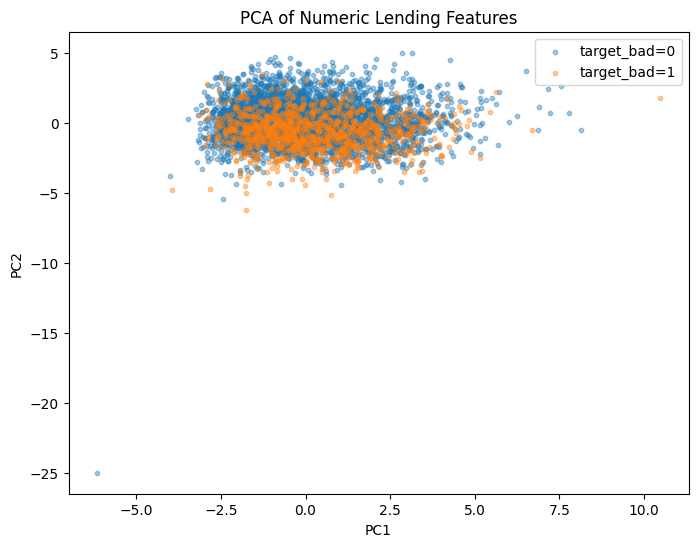

Explained variance ratio: [0.18304057 0.12524742]


In [8]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pca_cols = [
    "loan_amnt", "term", "int_rate", "installment", "annual_inc", "dti",
    "fico_avg", "delinq_2yrs", "inq_last_6mths", "open_acc",
    "pub_rec", "revol_bal", "revol_util", "total_acc", "mort_acc",
    "pub_rec_bankruptcies"
]

pca_cols = [c for c in pca_cols if c in df_model.columns]

X_num = df_model[pca_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_num_imp = imputer.fit_transform(X_num)
X_num_scaled = scaler.fit_transform(X_num_imp)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_num_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "target_bad": df_model["target_bad"].values
})

sample_plot_df = plot_df.sample(min(5000, len(plot_df)), random_state=42)

plt.figure(figsize=(8, 6))
for label in [0, 1]:
    subset = sample_plot_df[sample_plot_df["target_bad"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.4, s=10, label=f"target_bad={label}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Numeric Lending Features")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)